In [10]:
# %pip install pandas
# %pip install librosa
# %pip install matplotlib
# %pip install numpy
# %pip install seaborn

In [11]:
import pandas as pd
import os
import librosa
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

In [12]:
data_path = "/Users/slama/Desktop/data science/msc/cmt307/project/archive/Respiratory_Sound_Database/Respiratory_Sound_Database"
audio_path = os.path.join(data_path, "audio_and_txt_files")
diagnosis_path = os.path.join(data_path, "patient_diagnosis.csv")
demographic_path = os.path.join(data_path, "demographic_info.txt")

In [13]:
df_diagnosis = pd.read_csv(diagnosis_path)
df_diagnosis.columns = ["patient_id","condition"]
df_demographic = pd.read_csv(demographic_path, sep=" ",header=None)
df_demographic.columns = ["patient_id", "age", "sex", "adult_bmi", "child_weight", "child_height"]
df_merge = pd.merge(df_demographic, df_diagnosis, on="patient_id", how="left")
print(df_merge.tail())

     patient_id    age  sex  adult_bmi  child_weight  child_height  condition
121         222  60.00    M        NaN           NaN           NaN       COPD
122         223    NaN  NaN        NaN           NaN           NaN       COPD
123         224  10.00    F        NaN          32.3         143.0    Healthy
124         225   0.83    M        NaN           7.8          74.0    Healthy
125         226   4.00    M        NaN          16.7         103.0  Pneumonia


In [14]:
counts = df_merge["condition"].value_counts()
print(counts)
# Large imbalance.
# Only 1 instance of asthma and only 2 instances of LRTI so it might be better to remove.

condition
COPD              64
Healthy           26
URTI              13
Bronchiectasis     7
Pneumonia          6
Bronchiolitis      6
LRTI               2
Asthma             1
Name: count, dtype: int64


In [15]:
records = []

for fname in os.listdir(audio_path):
    if not fname.endswith(".txt"):
        continue

    parts = fname.replace(".txt", "").split("_")
    patient_id = int(parts[0])
    chest_loc = parts[2]
    acq_mode = parts[3]
    device = parts[4]

    with open(os.path.join(audio_path, fname)) as f:
        for line in f:
            cols = line.strip().split("\t")
            start, end, crackle, wheeze = float(cols[0]), float(cols[1]), int(cols[2]), int(cols[3])
            records.append({
                "patient_id": patient_id,
                "chest_location": chest_loc,
                "acquisition_mode": acq_mode,
                "device": device,
                "start": start,
                "end": end,
                "crackle": crackle,
                "wheeze": wheeze,
                "duration": end - start
            })

ann_df = pd.DataFrame(records)
ann_df = ann_df.merge(df_diagnosis, on="patient_id", how="left")
print(ann_df.shape)
print(ann_df.head())

(6898, 10)
   patient_id chest_location acquisition_mode    device  start    end  \
0         148             Al               sc  Meditron  0.022  0.364   
1         148             Al               sc  Meditron  0.364  2.436   
2         148             Al               sc  Meditron  2.436  4.636   
3         148             Al               sc  Meditron  4.636  6.793   
4         148             Al               sc  Meditron  6.793  8.750   

   crackle  wheeze  duration condition  
0        0       0     0.342      URTI  
1        0       0     2.072      URTI  
2        0       0     2.200      URTI  
3        0       0     2.157      URTI  
4        0       0     1.957      URTI  


In [16]:
audio_info = []

for fname in os.listdir(audio_path):
    if not fname.endswith(".wav"):
        continue
    path = os.path.join(audio_path, fname)
    y, sr = librosa.load(path, sr=None)
    duration = librosa.get_duration(y=y, sr=sr)
    audio_info.append({
        "filename": fname,
        "sample_rate": sr,
        "duration": duration,
        "samples": len(y)
    })

audio_df = pd.DataFrame(audio_info)
print("Sample rates:", audio_df["sample_rate"].unique())
print(audio_df["duration"].describe())

Sample rates: [44100  4000 10000]
count    920.000000
mean      21.492424
std        8.307421
min        7.856000
25%       20.000000
50%       20.000000
75%       20.000000
max       86.200000
Name: duration, dtype: float64


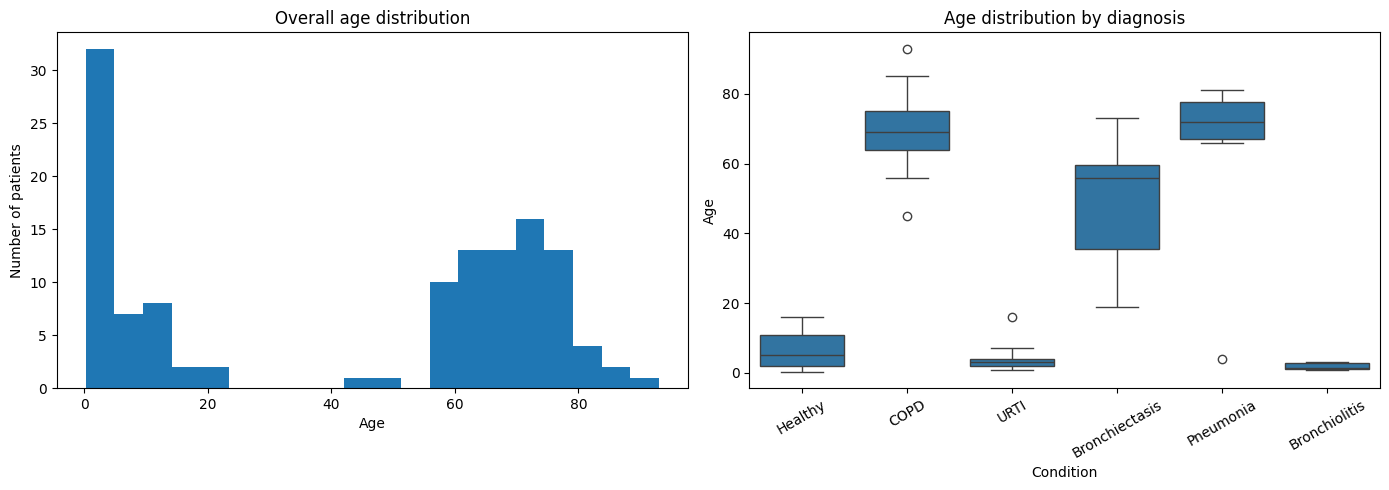

In [17]:
# Age analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_merge["age"].dropna(), bins=20)
axes[0].set_title("Overall age distribution", fontsize=12)
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Number of patients")

conditions = df_merge["condition"].value_counts()
conditions = conditions[conditions >= 3].index.tolist()
df_conditions = df_merge[df_merge["condition"].isin(conditions)]

sns.boxplot(data=df_conditions, x="condition", y="age", ax=axes[1])
axes[1].set_title("Age distribution by diagnosis", fontsize=12)
axes[1].set_xlabel("Condition")
axes[1].set_ylabel("Age")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

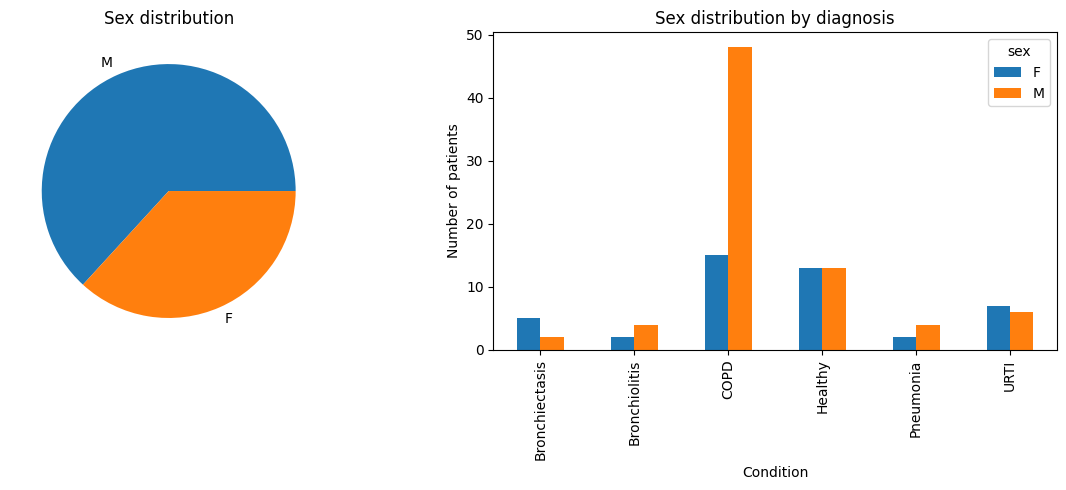

In [18]:
# Sex analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sex_counts = df_merge["sex"].value_counts()
axes[0].pie(sex_counts, labels=sex_counts.index)
axes[0].set_title("Sex distribution", fontsize=12)

sex_by_cond = (df_merge[df_merge["condition"].isin(conditions)]
               .groupby(["condition", "sex"])
               .size()
               .unstack(fill_value=0))
sex_by_cond.plot(kind="bar", ax=axes[1])
axes[1].set_title("Sex distribution by diagnosis", fontsize=12)
axes[1].set_xlabel("Condition")
axes[1].set_ylabel("Number of patients")
plt.tight_layout()
plt.show()

In [19]:
ct = pd.crosstab(df_merge["sex"], df_merge["condition"])
chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
print(f"chi-squared={chi2:.2f}, df={dof}, p={p_chi:.4f}")
# As the p-value < 0.05, sex distribution differs significantly across conditions.

chi-squared=14.77, df=7, p=0.0391


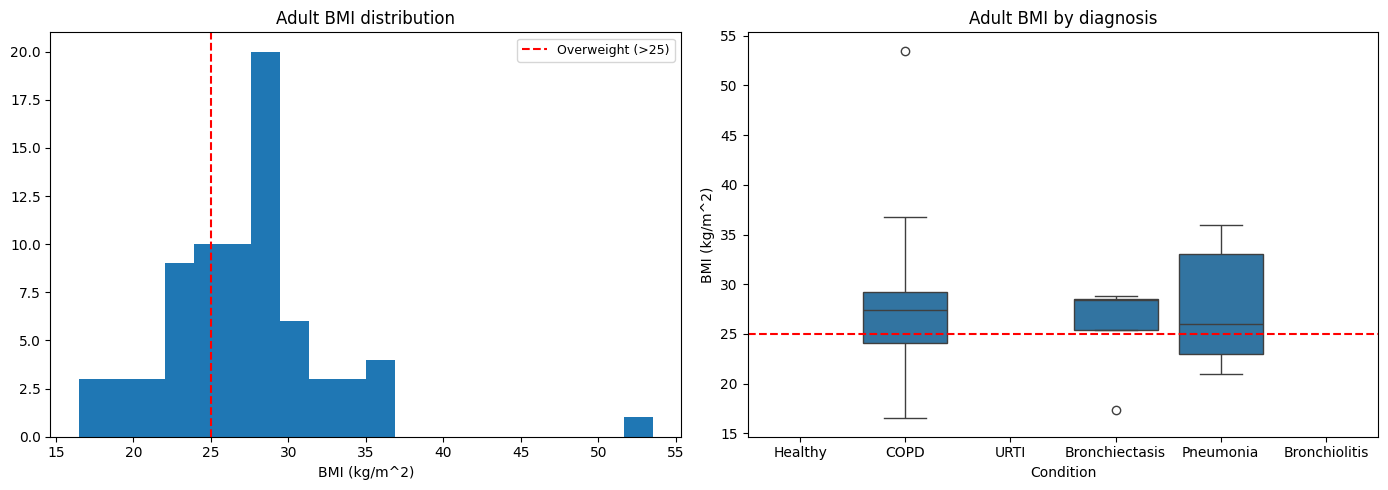

In [20]:
# BMI analysis for adults
adult_df = df_merge[df_merge["adult_bmi"].notna().notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].hist(adult_df["adult_bmi"], bins=20)
axes[0].axvline(25.0, color="red",    linestyle="--", label="Overweight (>25)")
axes[0].set_title("Adult BMI distribution", fontsize=12)
axes[0].set_xlabel("BMI (kg/m^2)")
axes[0].legend(fontsize=9)

adult_df = adult_df[adult_df["condition"].isin(conditions)]
sns.boxplot(data=adult_df, x="condition", y="adult_bmi", ax=axes[1])
axes[1].axhline(25.0, color="red",    linestyle="--", label="Overweight (>25)")
axes[1].set_title("Adult BMI by diagnosis", fontsize=12)
axes[1].set_xlabel("Condition")
axes[1].set_ylabel("BMI (kg/m^2)")
plt.tight_layout()
plt.show()

In [21]:
# Statistical test # line 132
groups = []

for _, group in adult_df.groupby("condition"):
    groups.append(group["age"].dropna().values)
h_stat, p_val = stats.kruskal(*groups)
print(f"H={h_stat:.2f}, p={p_val:.5f}")
# As the p-value < 0.05, age distributions differ significantly across conditions.

H=86.64, p=0.00000


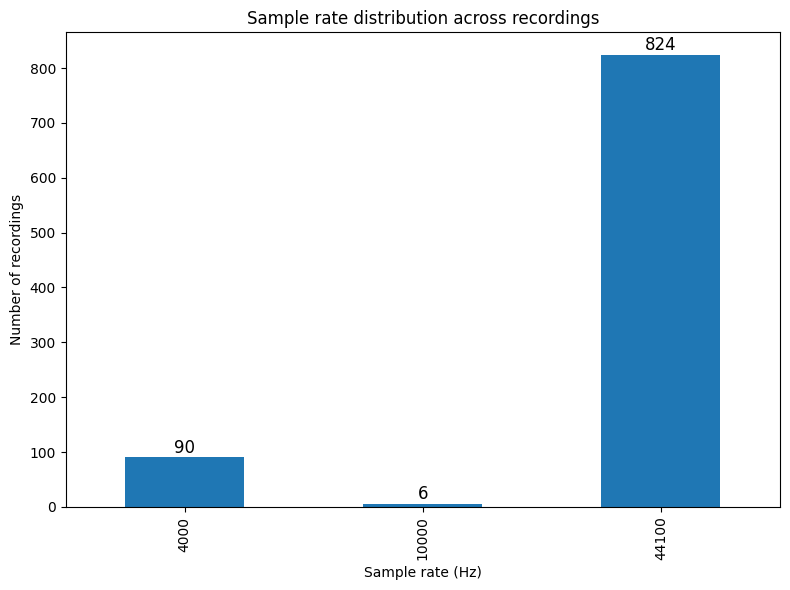

In [22]:
sr_counts = audio_df["sample_rate"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8,6))
sr_counts.plot(kind="bar", ax=ax)
ax.set_title("Sample rate distribution across recordings", fontsize=12)
ax.set_xlabel("Sample rate (Hz)")
ax.set_ylabel("Number of recordings")
for bar, count in zip(ax.patches, sr_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(count), ha="center", va="bottom", fontsize=12)
plt.tight_layout()
plt.show()

In [23]:
def plot_features(f_path, label):
    y, sr = librosa.load(f_path)

    plt.figure(figsize=(12, 8))
    # 1. Waveform
    plt.subplot(2, 1, 1)
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Waveform: {label}")
    
    # 2. Spectrogram
    plt.subplot(2, 1, 2)
    d = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img = librosa.display.specshow(d, sr=sr, x_axis="time", y_axis="log")
    plt.title(f"Spectrogram: {label}")
    plt.colorbar(img, format="%+2.0f dB")

    plt.tight_layout()
    plt.show()

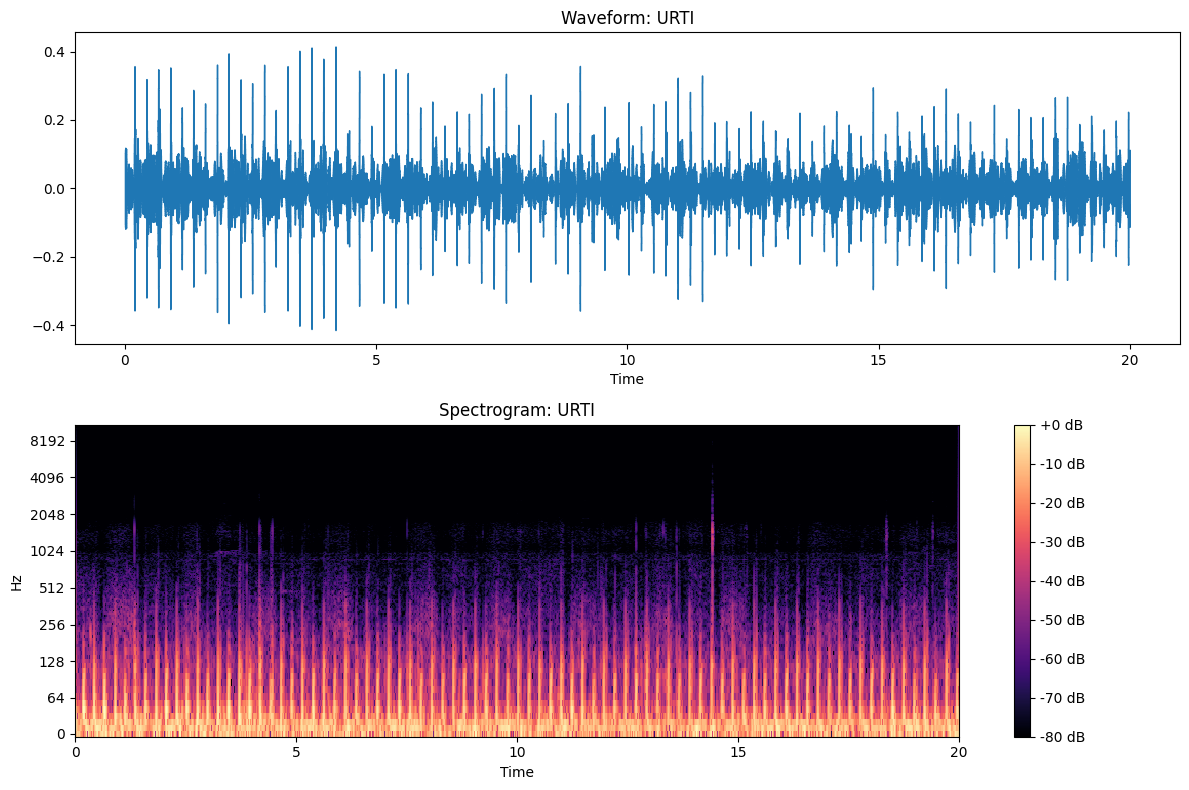

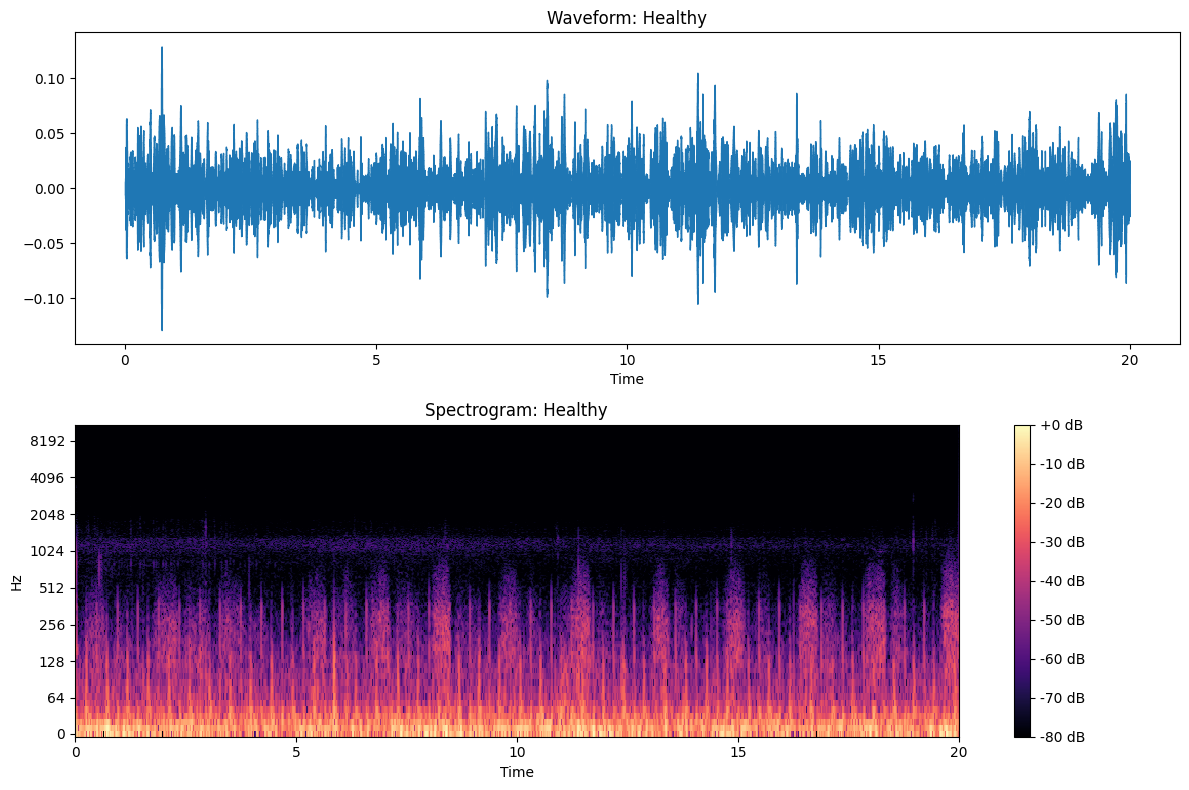

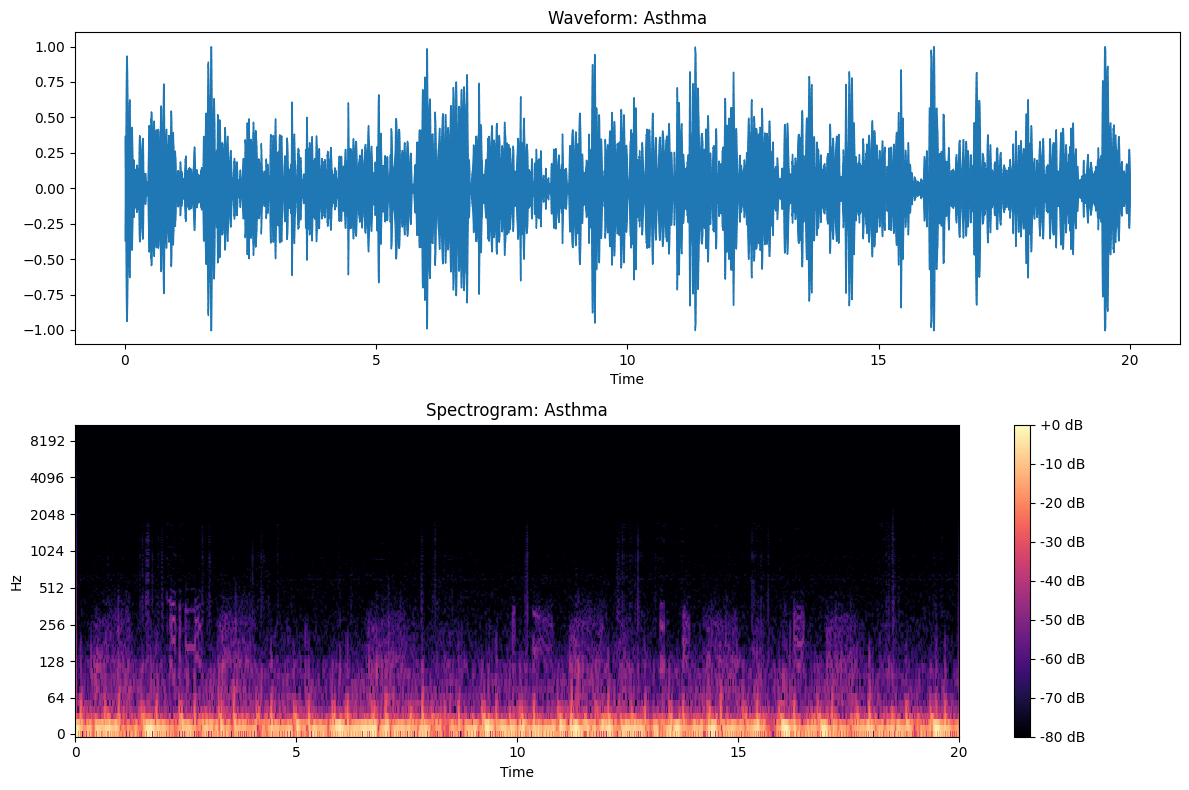

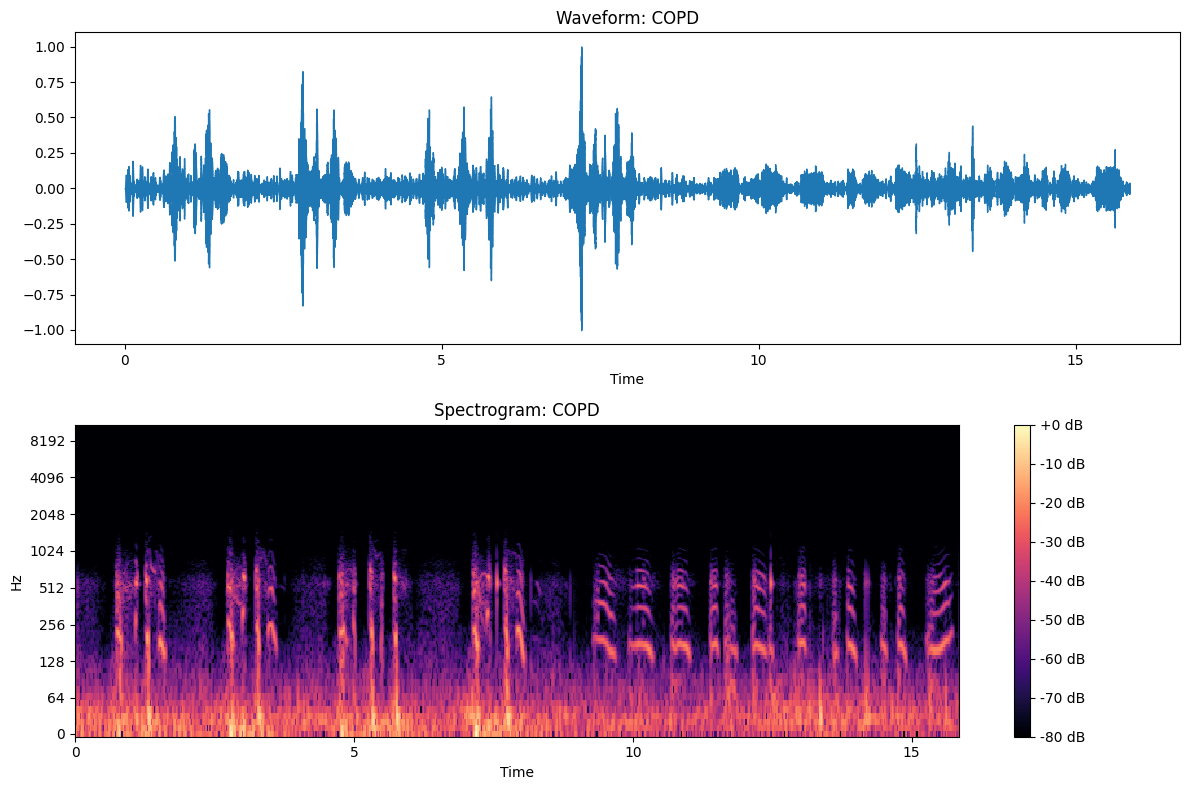

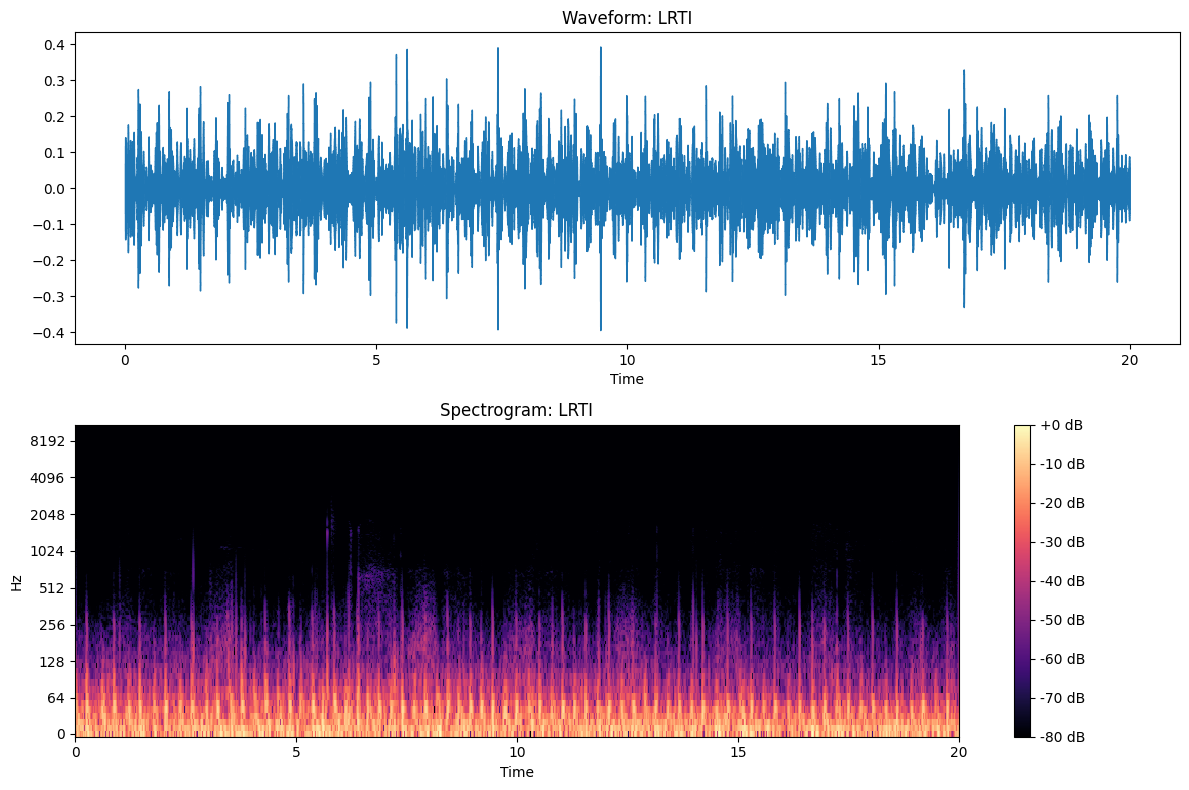

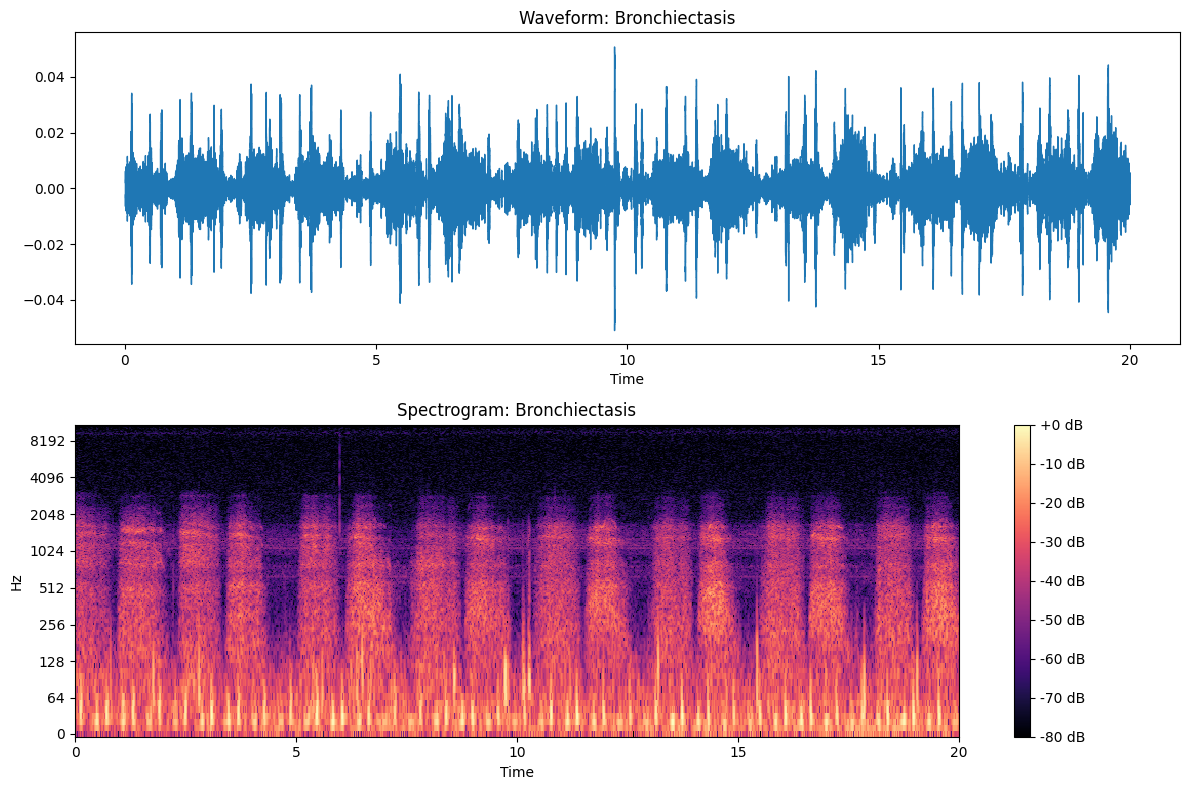

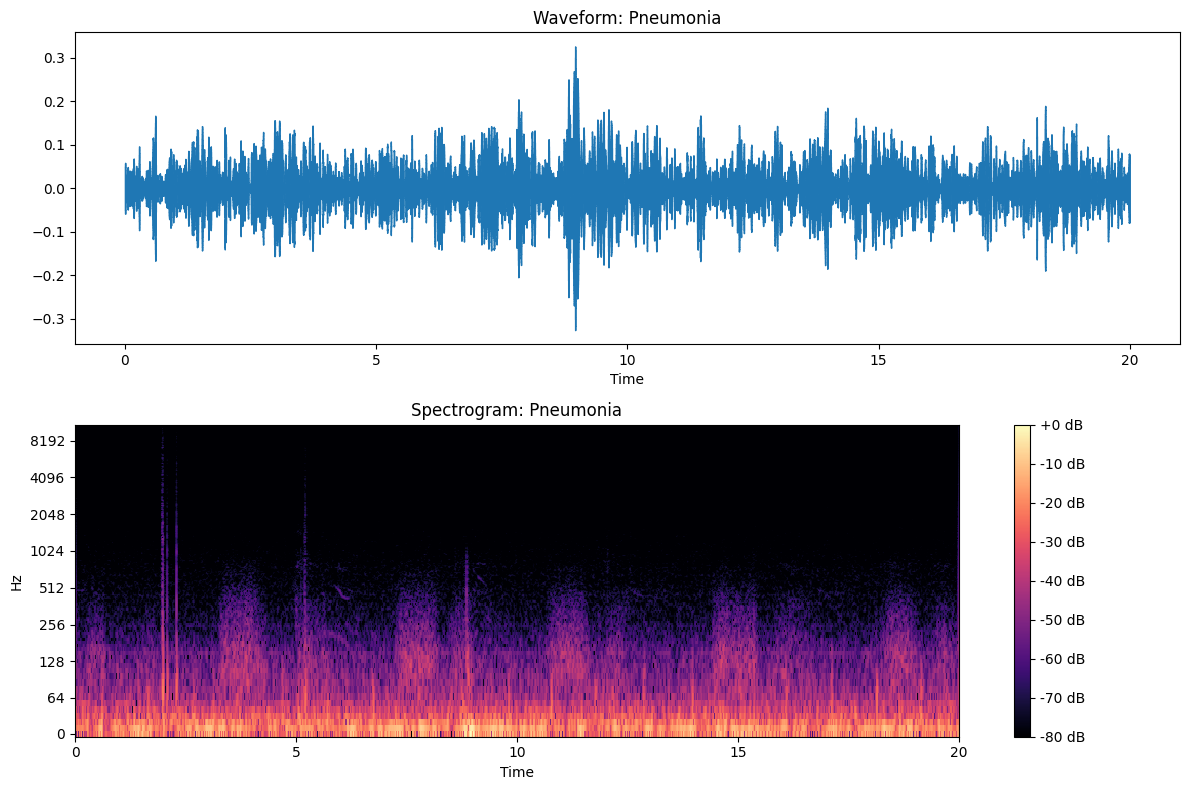

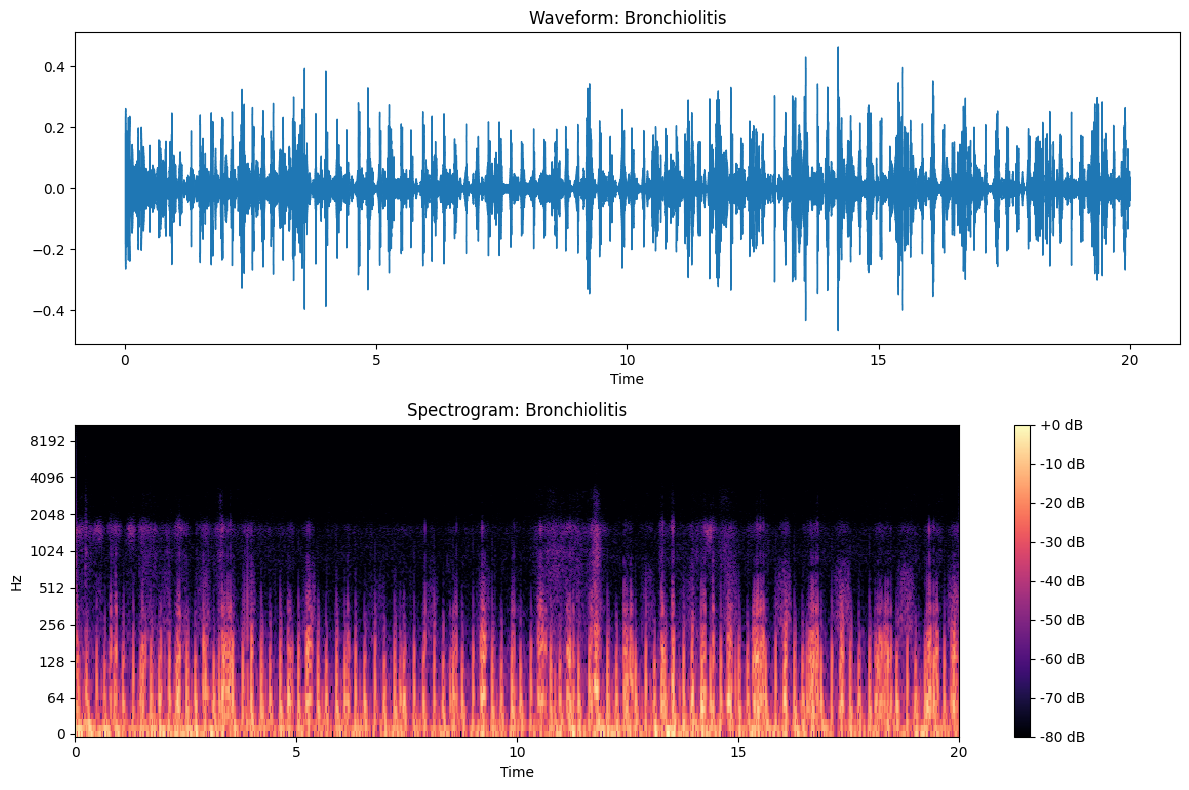

In [24]:
# 101 URTI
plot_features(os.path.join(audio_path, "101_1b1_Al_sc_Meditron.wav"), "URTI")
# 102 Healthy
plot_features(os.path.join(audio_path, "102_1b1_Ar_sc_Meditron.wav"), "Healthy")
# 103 Asthma
plot_features(os.path.join(audio_path, "103_2b2_Ar_mc_LittC2SE.wav"), "Asthma")
# 104 COPD
plot_features(os.path.join(audio_path, "104_1b1_Al_sc_Litt3200.wav"), "COPD")
# 108 LRTI
plot_features(os.path.join(audio_path, "108_1b1_Al_sc_Meditron.wav"), "LRTI")
# 111 Bronchiectasis
plot_features(os.path.join(audio_path, "111_1b2_Tc_sc_Meditron.wav"), "Bronchiectasis")
# 122 Pneumonia
plot_features(os.path.join(audio_path, "122_2b1_Al_mc_LittC2SE.wav"), "Pneumonia")
# 149 Bronchiolitis
plot_features(os.path.join(audio_path, "149_1b1_Al_sc_Meditron.wav"), "Bronchiolitis")


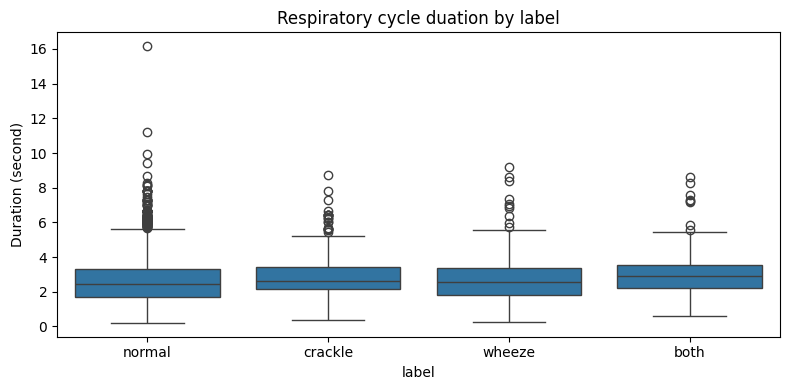

                count       mean        std   min    25%   50%     75%    max
condition                                                                    
Asthma            1.0   6.000000        NaN   6.0   6.00   6.0    6.00    6.0
Bronchiectasis    7.0  14.857143  12.185081   6.0   7.50  11.0   15.50   41.0
Bronchiolitis     6.0  26.666667  13.125040  13.0  19.75  24.5   27.75   51.0
COPD             64.0  89.781250  79.153953   5.0  39.25  67.5  126.75  507.0
Healthy          26.0  12.384615   7.321622   4.0   8.00  10.5   14.00   42.0
LRTI              2.0  16.000000  11.313708   8.0  12.00  16.0   20.00   24.0
Pneumonia         6.0  47.500000  33.237028  24.0  27.25  35.5   49.00  112.0
URTI             13.0  16.923077  15.375638   4.0   9.00  11.0   17.00   62.0


In [25]:
def create_label(row):
    if row["crackle"] == 1 and row["wheeze"] == 1:
        return "both"
    if row["crackle"] == 1:
        return "crackle"
    if row["wheeze"] == 1:
        return "wheeze"
    else:
        return "normal"

ann_df_copy = ann_df.copy()
ann_df_copy["label"] = ann_df_copy.apply(create_label, axis=1)
# print(ann_df_copy.head())

plt.figure(figsize=(8,4))
sns.boxplot(data=ann_df_copy, x="label", y="duration", order=["normal", "crackle", "wheeze", "both"])
plt.title("Respiratory cycle duation by label")
plt.ylabel("Duration (second)")
plt.tight_layout()
plt.show()

# Crackle/wheeze rate per condition
rate = ann_df_copy.groupby("condition")[["crackle","wheeze"]].mean().round(3)

patient_summary = ann_df_copy.groupby("patient_id").agg(
    n_cycles = ("label", "count"),
    crackle_rate = ("crackle", "mean"),
    wheeze_rate = ("wheeze", "mean"),
    condition = ("condition", "first")
)
print(patient_summary.groupby("condition")["n_cycles"].describe())

In [26]:
# Statistical tests on cycle-level features
# H0: 
label_groups = []

for _, group in ann_df_copy.groupby("label"):
    label_groups.append(group["duration"])
h_dura, p_dura = stats.kruskal(*label_groups)
print(f"H={h_dura:.2f}, p={p_dura:.4f}")
# As p-value < 0.05, the duration of respiratory cycles differ significantly across labels.

H=133.92, p=0.0000


In [27]:
def get_mfcc_info(path, n_mfcc=13):
    y, sr = librosa.load(path, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return {"mean": mfcc.mean(axis=1), "std": mfcc.std(axis=1)}

In [28]:
examples = {
"URTI": "101_1b1_Al_sc_Meditron.wav",
"Healthy": "102_1b1_Ar_sc_Meditron.wav",
"Asthma": "103_2b2_Ar_mc_LittC2SE.wav",
"COPD": "104_1b1_Al_sc_Litt3200.wav",
"LRTI": "108_1b1_Al_sc_Meditron.wav",
"Bronchiectasis": "111_1b2_Tc_sc_Meditron.wav",
"Pneumonia": "122_2b1_Al_mc_LittC2SE.wav",
"Bronchiolitis": "149_1b1_Al_sc_Meditron.wav"
}

In [29]:
mfcc_means = {}
n_mfcc = 13

for condition, fname in examples.items():
    fpath = os.path.join(audio_path, fname)
    info = get_mfcc_info(fpath)
    mfcc_means[condition] = info["mean"]

mfcc_labels = []

for i in range(n_mfcc):
    label_name = f"MFCC-{i+1}"
    mfcc_labels.append(label_name)

mfcc_mean_df = pd.DataFrame(mfcc_means, index=mfcc_labels)

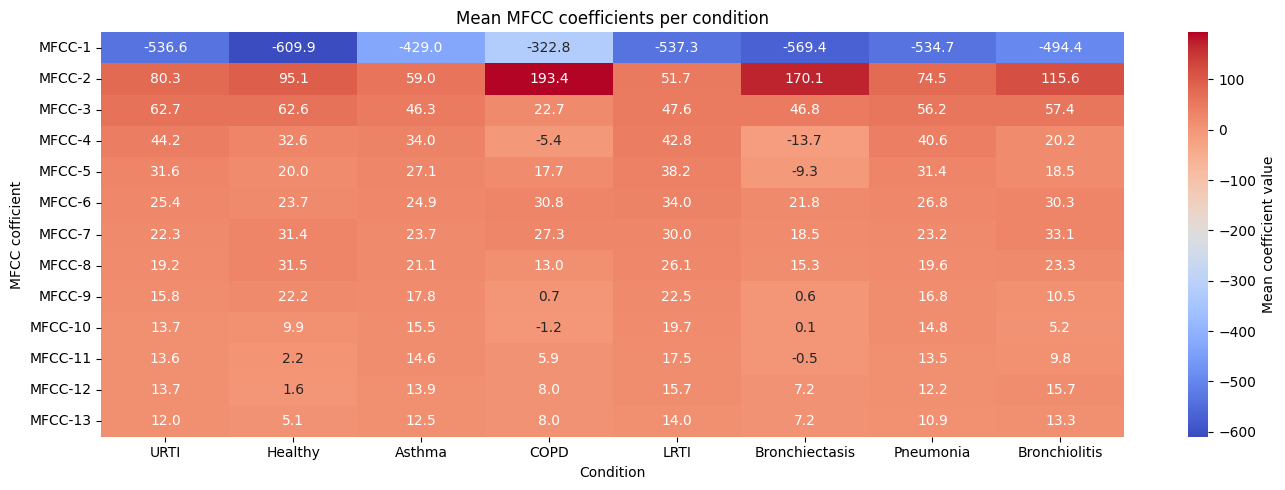

In [30]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(mfcc_mean_df, annot=True, fmt=".1f", cmap="coolwarm",
            ax=ax, cbar_kws={"label": "Mean coefficient value"})
ax.set_title("Mean MFCC coefficients per condition",
             fontsize=12)
ax.set_xlabel("Condition")
ax.set_ylabel("MFCC cofficient")
plt.tight_layout()
plt.show()

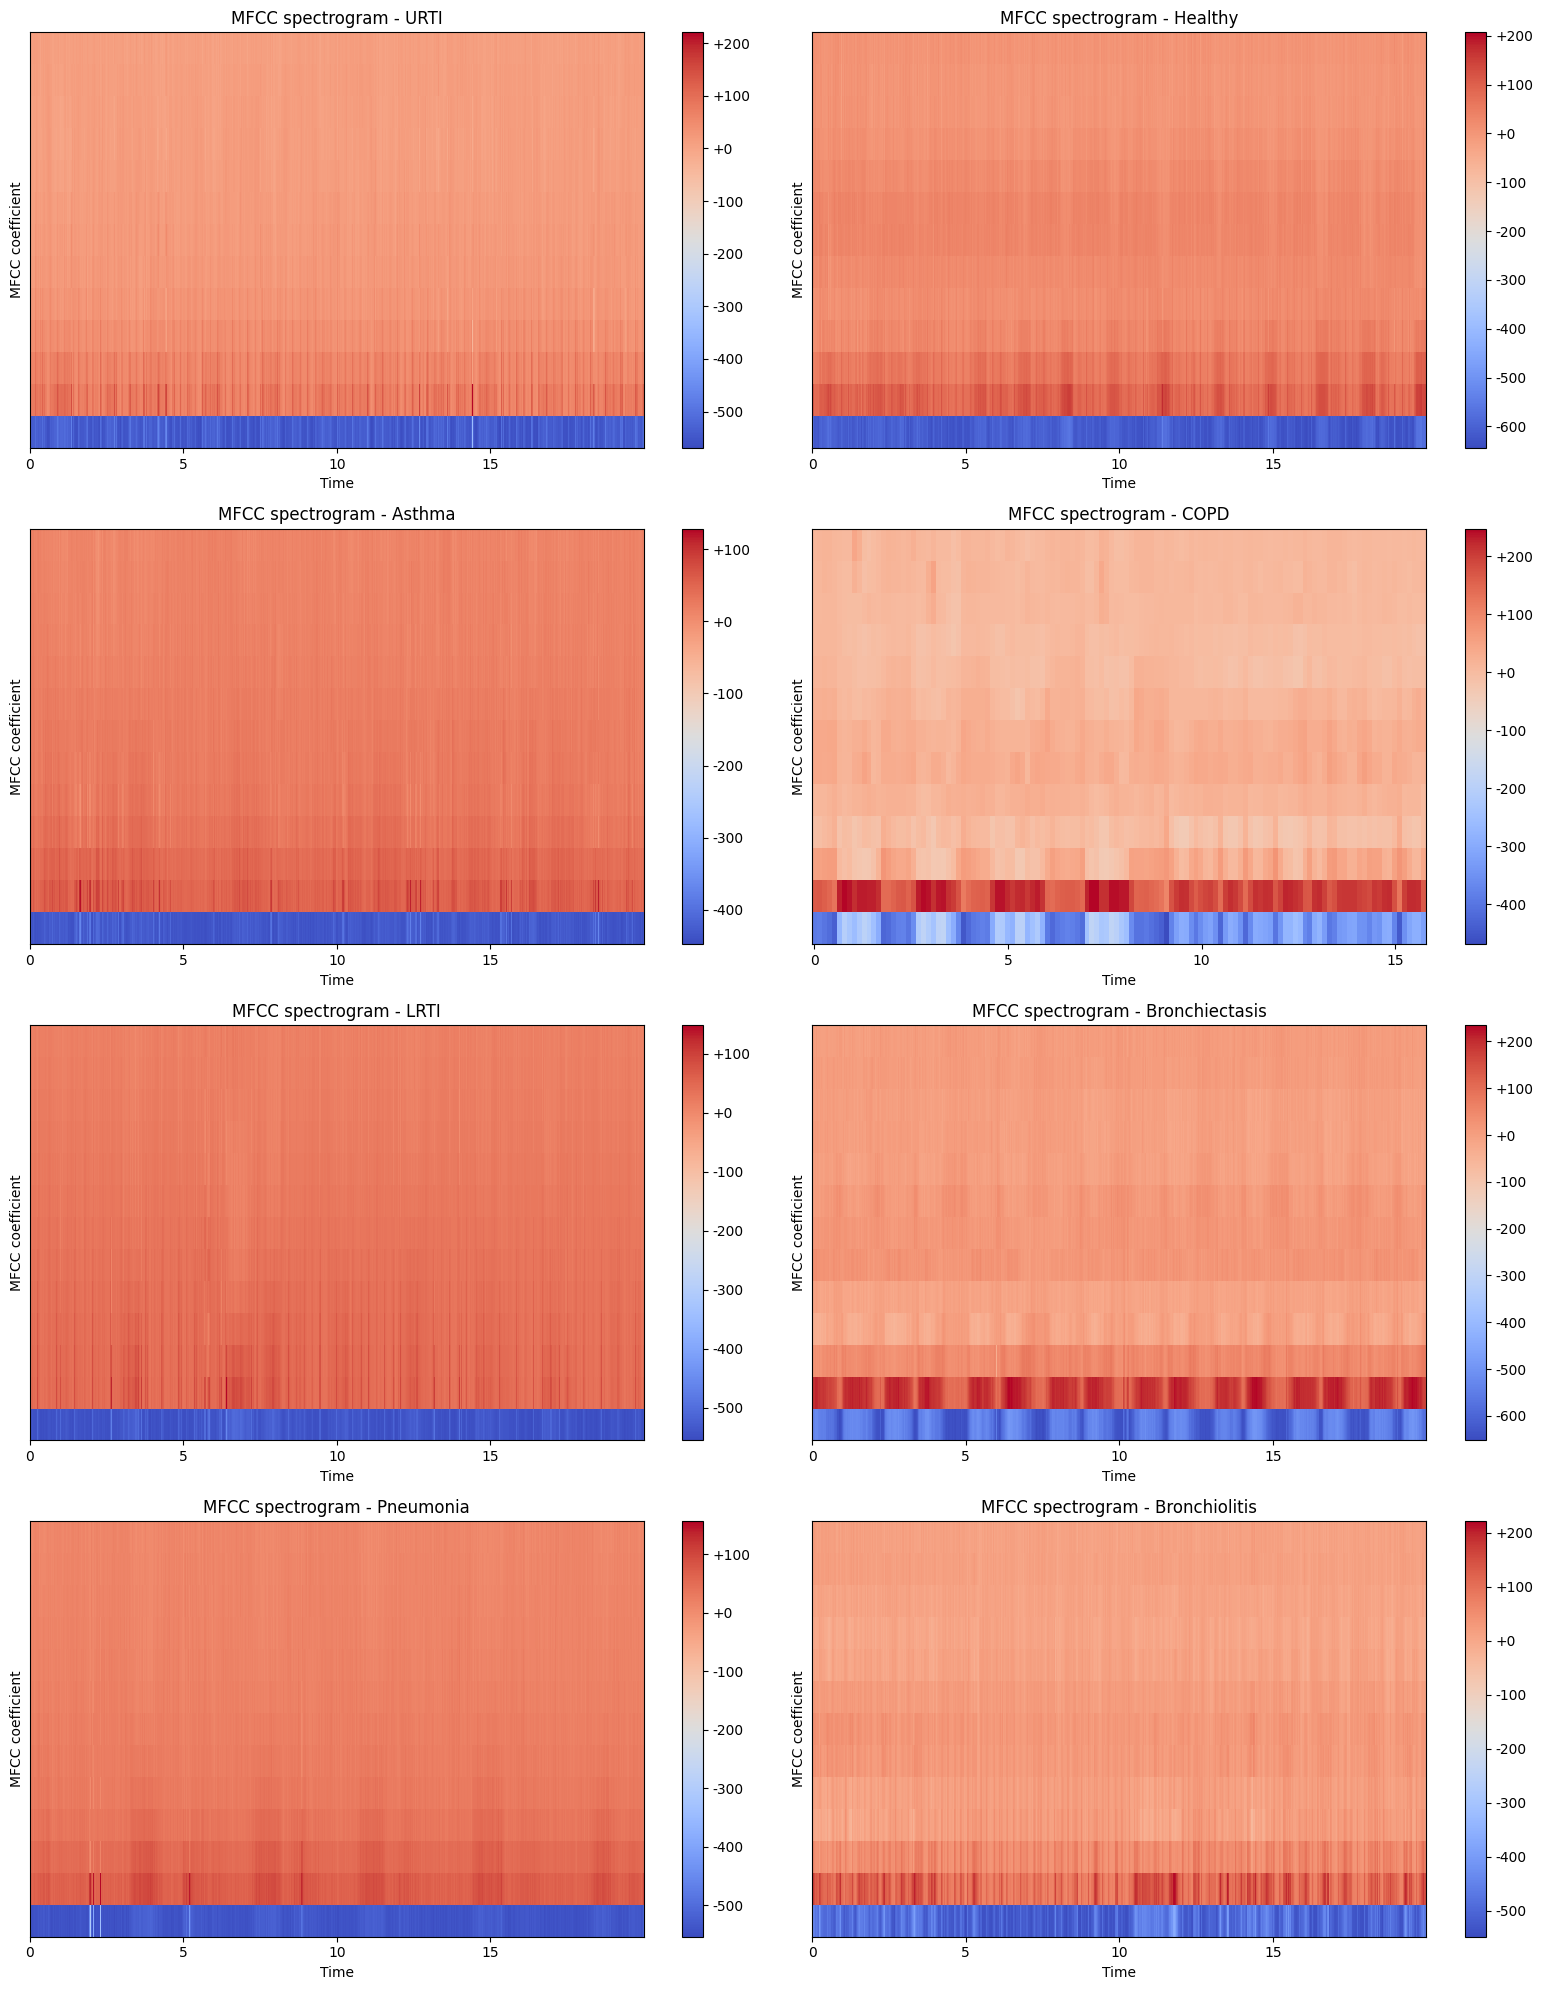

In [31]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for ax, (condition, fname) in zip(axes, examples.items()):
    fpath = os.path.join(audio_path, fname)
    y, sr = librosa.load(fpath, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    img = librosa.display.specshow(mfcc, sr=sr, x_axis="time", ax=ax, cmap="coolwarm")
    ax.set_title(f"MFCC spectrogram - {condition}", fontsize=12)
    ax.set_ylabel("MFCC coefficient")
    fig.colorbar(img, ax=ax, format="%+.0f")

plt.tight_layout()
plt.show()

In [32]:
rate = ann_df_copy.groupby("condition")[["crackle", "wheeze"]].mean().round(3)
print(rate.to_string())

                crackle  wheeze
condition                      
Asthma            0.000   0.667
Bronchiectasis    0.212   0.394
Bronchiolitis     0.125   0.431
COPD              0.395   0.216
Healthy           0.053   0.009
LRTI              0.000   0.031
Pneumonia         0.074   0.084
URTI              0.095   0.036


In [33]:
# H0:
ct2 = pd.crosstab(ann_df_copy["label"], ann_df_copy["condition"])
chi2_2, p2, dof2, _ = stats.chi2_contingency(ct2)
print(f"Chi-squared={chi2_2}:.2f, df={dof2}, p={p2:.4f}")
# As p-value < 0.05, the distribution of wheezes and crackles differs significantly across conditions.

Chi-squared=708.7727358551961:.2f, df=21, p=0.0000


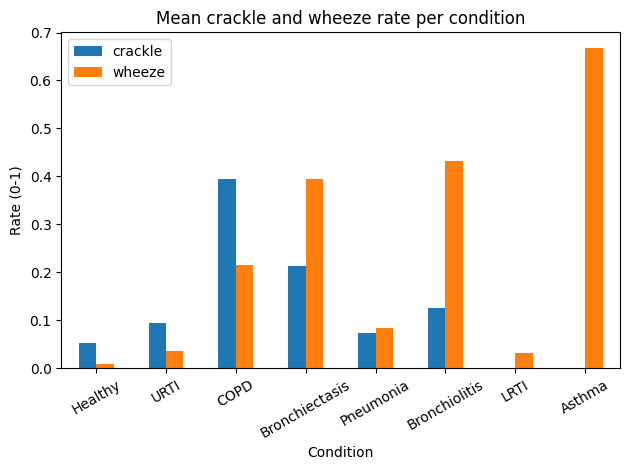

In [34]:
conditions = ["Healthy", "URTI", "COPD", "Bronchiectasis", "Pneumonia", "Bronchiolitis",
              "LRTI", "Asthma"]
rate_plot = []

for condition in conditions:
    if condition in rate.index:
        rate_plot.append(condition)

rate_plot_df = rate.reindex(rate_plot)
ax = rate_plot_df.plot(kind="bar")
ax.set_title("Mean crackle and wheeze rate per condition", fontsize=12)
ax.set_xlabel("Condition")
ax.set_ylabel("Rate (0-1)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

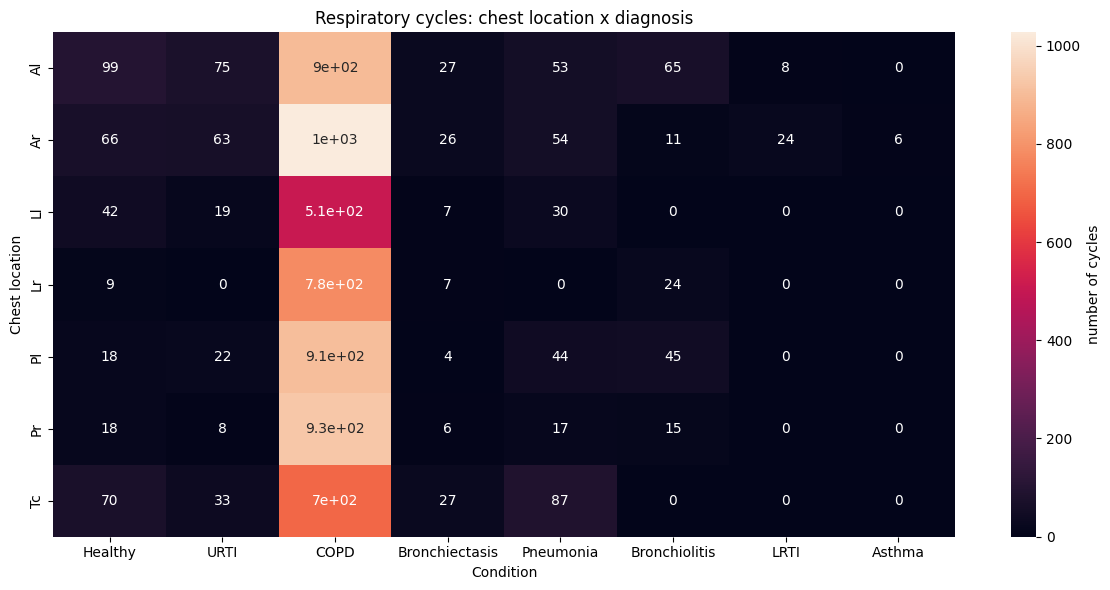

In [35]:
pivot_df = (ann_df_copy.groupby(["chest_location", "condition"])
        .size()
        .unstack(fill_value=0))

pivot = []

for condition in conditions:
    if condition in pivot_df.columns:
        pivot.append(condition)

pi_df = pivot_df.reindex(columns=pivot)

fig, ax = plt.subplots(figsize=(12,6))
sns.heatmap(pi_df, annot=True, cbar_kws={"label": "number of cycles"})
ax.set_title("Respiratory cycles: chest location x diagnosis", fontsize=12)
ax.set_xlabel("Condition")
ax.set_ylabel("Chest location")
plt.tight_layout()
plt.show()